<a href="https://colab.research.google.com/github/prachitshukla/Team-2/blob/music_sentiment_analysis/Copy_of_M5_Mini_Hackathon_Classification_of_Emotions_of_Musical_Audio_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/058bf9c00aeb4e30967d10d11e2441ae) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [101]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [2]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [3]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.0.0 requires urllib3<3,>=1.25.3, but you have urllib3 1.24.3 which is incompatible.
torchdata 0.11.0 requires urllib3>=1.25, but you have urllib3 1.24.3 which is incompatible.
sentry-sdk 2.29.1 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.
distributed 2024.12.1 requires urllib3>=1.26.5, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [ ]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c classification-of-emotions-of-musical-audio-files
!unzip classification-of-emotions-of-musical-audio-files.zip

### YOUR CODING STARTS FROM HERE

### Import Neccesary Packages

In [ ]:
# YOUR CODE HERE
! pip install librosa

In [90]:
import torch
import os
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import librosa
import librosa.display
from pathlib import Path
from matplotlib import pyplot as plt
import torch.nn.functional as F


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


import random


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

### **Stage 1:** Load the Train data audio files (1 point)




In [17]:
#Load from Train Set
data_path = './Train/Train'

def get_files(path, extension='.wav'):
    return list(path.rglob(f'*{extension}'))


label_id = {"01": "happy",
            '02': "sad"
           }

# Get all files from the ravdess data folders
all_files = get_files(Path(data_path))
print(len(all_files))




1873


#### Play the sample audio

In [22]:
import IPython.display as ipd
ipd.Audio(filename=os.path.join(os.getcwd(), all_files[1872]), rate=48000)

### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



<class 'list'>
1873
{'file': PosixPath('Train/Train/Happy/Happy38916.wav'), 'label': 'happy'}


<Axes: xlabel='label', ylabel='count'>

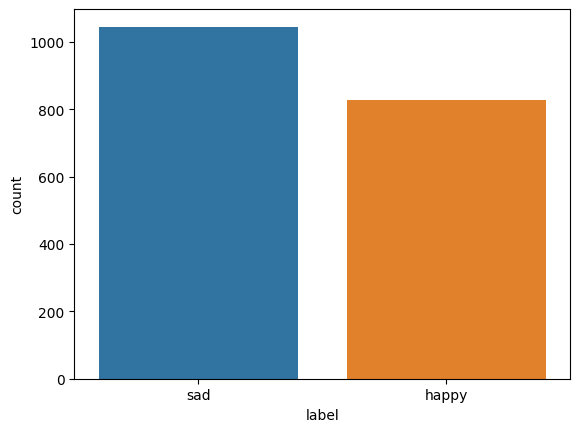

In [55]:
# YOUR CODE HERE
labels = list(map(lambda f: {"file": f, "label": "happy" if "happy" in os.path.basename(f).lower() else "sad"}, all_files))
print(type(labels))
print(len(labels))
print(labels[1872])


df_labels = pd.DataFrame(labels)
df_labels.head()
df_labels.tail()

sns.countplot(data=df_labels, x="label", hue='label')
#plt.show()


#### Visualize sample audio signal using librosa

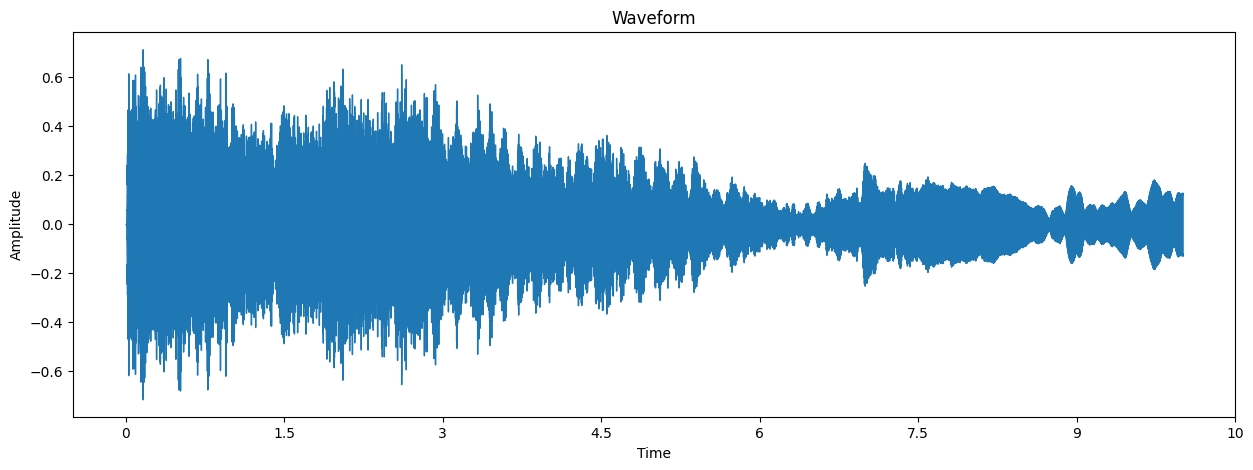

In [63]:
# YOUR CODE HERE
sample_audio_path = os.path.join(os.getcwd(), all_files[1872])

# librosa is used for analyzing and extracting features of an audio signal
data, sampling_rate = librosa.load(sample_audio_path)
plt.figure(figsize=(15, 5))


# librosa.display.waveshow is used to plot waveform of amplitude vs time
librosa.display.waveshow(data, sr=sampling_rate)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()

### **Stage 3:** Feature extraction (2 points)


In [ ]:
#suffle array values
print(all_files)
random.shuffle(all_files)
print('*'.center(80,'*'))
print(all_files)

In [72]:
def extract_mfcc(file_path, n_mfcc=13):
    data, sampling_rate = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n_mfcc)

    # Use mean and standard deviation across time (axis=1)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    return np.hstack([mfcc_mean, mfcc_std])

In [ ]:
import os



def load_dataset(root_dir):
    features_list = []
    labels = []
    for dir in os.listdir(root_dir):
      for filename in os.listdir(os.path.join(root_dir, dir)):
          if filename.endswith(".wav"):
              print(filename)
              file_path = os.path.join(root_dir, dir, filename)
              mfcc_features = extract_mfcc(file_path)

              # Label based on filename (basic example)
              if 'happy' in filename.lower():
                label = 'happy'
              elif 'sad' in filename.lower():
                label = 'sad'
              else:
                continue  # skip unlabeled files

              features_list.append(mfcc_features)
              labels.append(label)
    return np.array(features_list), np.array(labels)

root_dir = "./Train/Train/"
feature_list_temp, labels_temp = load_dataset(root_dir)

print(len(feature_list_temp), len(labels_temp))

In [85]:
print(len(labels))
df_feature_list = pd.DataFrame(feature_list_temp)
print(df_feature_list.shape)
df_feature_list.head()
df_feature_list.tail()

1873
(1873, 26)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1868,-187.762070,142.278625,12.563207,0.489427,9.907181,27.450850,8.077879,5.824817,-0.264838,5.065334,2.628246,6.029201,-3.519004,91.938652,56.226372,32.125919,21.409496,18.327623,18.800169,13.446939,11.338286,11.035316,9.120237,10.096210,8.934901,9.522269
1869,-160.864136,121.201332,18.959644,54.038097,2.349428,26.434599,0.934025,23.137405,4.272841,12.730049,6.514732,5.068604,-2.093398,49.032593,25.815304,16.253063,13.427801,11.424750,8.240350,9.296163,9.421767,10.141788,7.943053,7.851299,7.180345,7.504715
1870,-118.159691,156.164139,-23.060442,33.186512,-3.468668,25.315832,-0.685681,13.854687,0.931849,11.519829,3.947016,7.549088,1.951964,51.260860,24.853588,22.612328,14.478132,10.588451,8.632493,9.416610,8.080693,8.689650,7.835819,6.752307,8.383433,6.888496
1871,-260.683533,204.979630,-12.382246,22.052881,20.556358,6.562513,7.236623,-0.396778,-1.238927,-0.985131,1.735127,3.138078,-3.173519,30.172358,15.960837,14.009135,11.281377,10.569650,8.958476,9.272134,7.970955,9.977012,10.313727,7.304482,7.090600,8.515379
1872,-295.398712,159.958160,-32.883503,2.423966,-6.197005,-5.024621,1.919467,12.248101,5.471960,-4.759150,-12.641730,-18.428038,-10.019235,101.830109,53.021770,24.770948,29.853550,10.831037,8.945956,10.140892,9.409244,7.112966,6.243608,14.057278,10.553303,7.277377


### **Stage 4:** Train the model  (4 points)


In [88]:
root_dir = "./Train/Train/"
data_array, label_list = load_dataset(root_dir)

print(len(data_array))
print(len(label_list))

<ipython-input-72-2451644810>:2: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(
<ipython-input-72-2451644810>:2: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1873
1873


In [91]:
lable_encoder = LabelEncoder()
label_encoded = lable_encoder.fit_transform(label_list)
print(label_encoded)

[1 1 1 ... 0 0 0]


In [92]:
X_train, X_test, y_train, y_test = train_test_split(data_array, label_encoded, test_size=0.2, random_state=42)

In [93]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [98]:
# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=lable_encoder.classes_))

Accuracy: 0.7493333333333333
Classification Report:
               precision    recall  f1-score   support

       happy       0.73      0.69      0.71       166
         sad       0.76      0.79      0.78       209

    accuracy                           0.75       375
   macro avg       0.75      0.74      0.74       375
weighted avg       0.75      0.75      0.75       375



In [100]:
#Train model on Full Train dataset
X_train, X_test, y_train, y_test = train_test_split(data_array, label_encoded, test_size=0.001, random_state=42)
print(len(X_train))

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

1871


RandomForestClassifier(random_state=42)

### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [142]:
#Prepaire Test Dataset

file_ids=[]
def load_dataset_test(root_dir):
    features_list = []
    for dir in os.listdir(root_dir):
      for filename in os.listdir(os.path.join(root_dir, dir)):
          if filename.endswith(".wav"):
              file_ids.append(filename)
              print(filename)
              file_path = os.path.join(root_dir, dir, filename)
              print(file_path)
              mfcc_features = extract_mfcc(file_path)

              features_list.append(mfcc_features)
    return np.array(features_list)


test_data_path = './Test/'
data_array_test = load_dataset_test(test_data_path)

print(len(data_array_test))
print(file_ids)

46.wav
./Test/Test/46.wav
216.wav
./Test/Test/216.wav
44.wav
./Test/Test/44.wav
36.wav
./Test/Test/36.wav
134.wav
./Test/Test/134.wav
218.wav
./Test/Test/218.wav
223.wav
./Test/Test/223.wav
167.wav
./Test/Test/167.wav
88.wav
./Test/Test/88.wav
23.wav
./Test/Test/23.wav
75.wav
./Test/Test/75.wav
102.wav
./Test/Test/102.wav
83.wav
./Test/Test/83.wav
142.wav
./Test/Test/142.wav
51.wav
./Test/Test/51.wav
156.wav
./Test/Test/156.wav
138.wav
./Test/Test/138.wav
70.wav
./Test/Test/70.wav
19.wav
./Test/Test/19.wav
157.wav
./Test/Test/157.wav
189.wav
./Test/Test/189.wav
95.wav
./Test/Test/95.wav
30.wav
./Test/Test/30.wav
33.wav
./Test/Test/33.wav
221.wav
./Test/Test/221.wav
24.wav
./Test/Test/24.wav
149.wav
./Test/Test/149.wav
143.wav
./Test/Test/143.wav
190.wav
./Test/Test/190.wav
150.wav
./Test/Test/150.wav
97.wav
./Test/Test/97.wav
103.wav
./Test/Test/103.wav
18.wav
./Test/Test/18.wav
129.wav
./Test/Test/129.wav
191.wav
./Test/Test/191.wav
177.wav
./Test/Test/177.wav
131.wav
./Test/Test/131.

In [125]:
print(len(data_array_test))
X_test = data_array_test
y_pred_test = model.predict(X_test)

253


In [128]:
print(type(y_pred_test))
print(y_pred_test)

<class 'numpy.ndarray'>
[1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0 1
 1 1 1 0 0 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1
 1 0 0 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 0 0 1
 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1]


In [149]:
# Get the max values from prediction

# From the max values decode the sentiments
predicted_test_sentiments = lable_encoder.inverse_transform(y_pred_test)
predicted_test_sentiments= np.array([sentiment.capitalize() for sentiment in predicted_test_sentiments])

print("Predicted sentiments (first 10):", predicted_test_sentiments[:10])


Predicted sentiments (first 10): ['Sad' 'Sad' 'Happy' 'Sad' 'Sad' 'Sad' 'Sad' 'Sad' 'Happy' 'Sad']


In [151]:
# Create a dataframe and add the Test_Id and predicted sentiment text to it
output_df = pd.DataFrame({'File Name': file_ids, 'Target': predicted_test_sentiments})

output_df.sort_values(by='File Name', inplace=True)
print(output_df.head(100))
# Write to CSV file
output_df.to_csv('sentiment_predictions.csv', index=False)

    File Name Target
52      1.wav    Sad
128    10.wav    Sad
61    100.wav  Happy
71    101.wav  Happy
11    102.wav    Sad
..        ...    ...
139   185.wav    Sad
166   186.wav    Sad
207   187.wav    Sad
145   188.wav    Sad
20    189.wav    Sad

[100 rows x 2 columns]
